In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from scipy import stats

sc = StandardScaler()
plt.style.use('seaborn-v0_8-pastel')

In [175]:
# import data: 2000 US natality data
natality_raw = pd.read_stata('/Users/katharinefbixby/Library/CloudStorage/OneDrive-Personal/Dartmouth/PH141 Regression/natality2000us.dta')

In [182]:
print(len(natality_raw))

print(natality_raw.describe())

4063823
        datayear       rectype      restatus      recwt         pldel  \
count  4063823.0  4.063823e+06  4.063823e+06  4063823.0  4.063823e+06   
mean      2000.0  1.248800e+00  1.273164e+00        1.0  1.024111e+00   
std          0.0  4.323175e-01  4.997403e-01        0.0  2.664103e-01   
min       2000.0  1.000000e+00  1.000000e+00        1.0  1.000000e+00   
25%       2000.0  1.000000e+00  1.000000e+00        1.0  1.000000e+00   
50%       2000.0  1.000000e+00  1.000000e+00        1.0  1.000000e+00   
75%       2000.0  1.000000e+00  1.000000e+00        1.0  1.000000e+00   
max       2000.0  2.000000e+00  4.000000e+00        1.0  9.000000e+00   

             pldel3      birattnd       regnocc        divocc      stsubocc  \
count  4.063823e+06  4.063823e+06  4.063823e+06  4.063823e+06  4.063823e+06   
mean   1.009844e+00  1.224987e+00  2.680035e+00  5.281264e+00  5.646161e+01   
std    9.948431e-02  6.532475e-01  1.020247e+00  2.523199e+00  2.554047e+01   
min    1.000000e+0

In [176]:
# list complication columns
complication_cols = ['febrile', 'meconium', 'rupture', 'abruptio', 'preplace', 'excebld', 'seizure', 'precip', 'prolong', 'dysfunc', 
                        'breech', 'cephalo', 'cord', 'anesthe', 'distress', 'otherlb']

# create complication column where 0: no complication, 1: complication
natality_raw['complication'] = np.where((natality_raw[complication_cols] == 1).any(axis=1), 1, 0)
natality_raw['smoker'] = np.where((natality_raw[['tobacco']] == 1).any(axis=1), 1, 0)

natality_nyc = natality_raw[(natality_raw['stnatexp'] == '34')]

# filtered dataframe
natality_trim = natality_nyc[['dbirwt', 'nprevis', 'dmage', 'wtgain', 'dgestat', 'smoker', 'complication']]

# filter out unknowns and limit birthweight
natality_std = natality_trim[(natality_trim['dbirwt'] != 9999) & (natality_trim['nprevis'] != 99) & (natality_trim['wtgain'] != 99) & (natality_trim['dgestat'] != 99)
                             & (natality_trim['dbirwt'] >= 0) & (natality_trim['dbirwt'] <= 6600)]


for column in natality_std.columns:
    print(column, min(natality_std[column]), max(natality_std[column]))
print(len(natality_std))

dbirwt 235 6135
nprevis 0 49
dmage 12 53
wtgain 0 98
dgestat 18 47
smoker 0 1
complication 0 1
110529


In [177]:
statistic, pvalue = stats.normaltest(natality_std[['dbirwt']])

print(f'Test Statistic: {statistic}')
print(f'P-value: {pvalue}')

Test Statistic: [17386.89145656]
P-value: [0.]


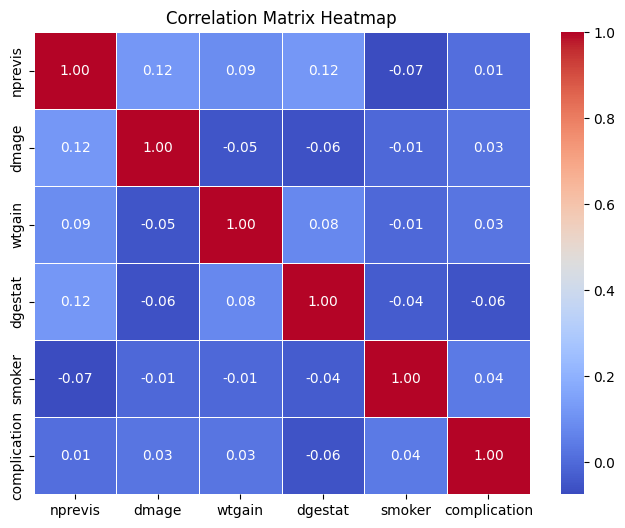

In [178]:
corrmat = natality_std.loc[:, natality_std.columns != 'dbirwt'].corr()

plt.figure(figsize=(8, 6)) # Optional: Adjusts the figure size
sns.heatmap(corrmat, 
            annot=True,      # Annotate cells with the correlation values
            cmap='coolwarm', # Color scheme (cool to warm colors)
            fmt='.2f',       # Format the annotations to two decimal places
            linewidths=0.5)  # Adds lines between cells

plt.title('Correlation Matrix Heatmap')
plt.show()

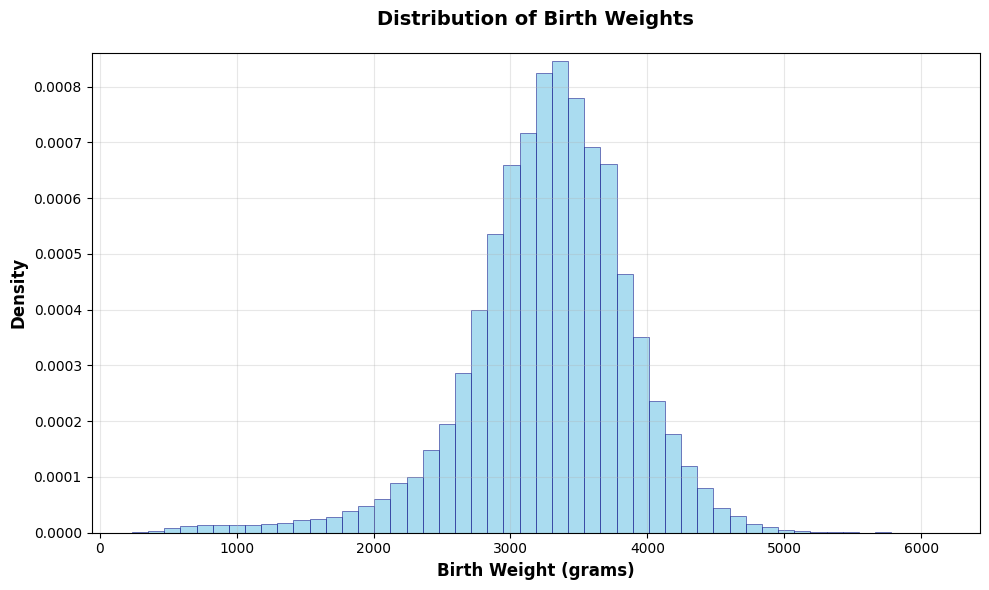

In [179]:
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(natality_std['dbirwt'], bins=50, alpha=0.7, color='skyblue', 
                          edgecolor='navy', linewidth=0.5, density=True)

ax.set_xlabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Birth Weights', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

# Add subtle variation to bars for visual appeal
for patch in patches: 
    patch.set_height(patch.get_height() * (1 + 0.1 * np.random.rand()))

plt.tight_layout()
plt.show()

In [180]:
# create test and training data
nat_train, nat_test = train_test_split(natality_std, test_size=0.4, random_state=57)
# check that size of each sums to size of the original
print('Training set size:', len(nat_train))
print('Test set size:',len(nat_test))
print(len(natality_std) == len(nat_test) + len(nat_train))

# create linear model
model = smf.ols('dbirwt ~ dgestat + wtgain + C(smoker)', data=nat_train).fit()

print(model.summary())

Training set size: 66317
Test set size: 44212
True
                            OLS Regression Results                            
Dep. Variable:                 dbirwt   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     9376.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:11:59   Log-Likelihood:            -5.0627e+05
No. Observations:               66317   AIC:                         1.013e+06
Df Residuals:                   66313   BIC:                         1.013e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

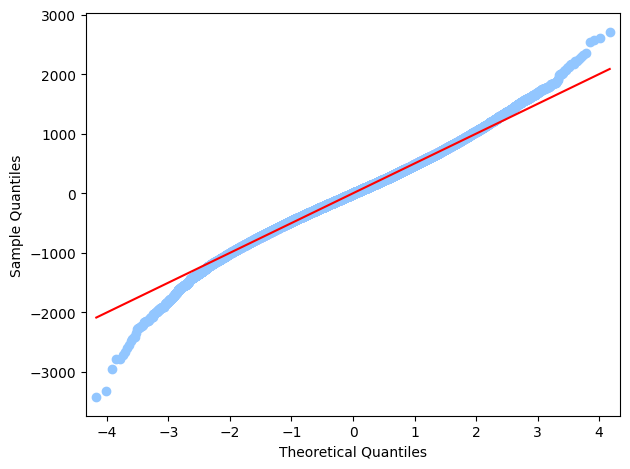

In [181]:
# call residulals from model
residuals = model.resid
# show qq plot
fig = sm.qqplot(residuals, line='s')
plt.tight_layout()
plt.show()